In [ ]:
using Pkg
Pkg.activate(".")
# Pkg.instantiate()
Pkg.status()

  Activating project at `c:\Users\MGAJ\OneDrive - Danmarks Tekniske Universitet\DTU\Kandidat\5_Semester\Speciale\discovering_hidden_physics\scripts`


Status `C:\Users\MGAJ\OneDrive - Danmarks Tekniske Universitet\DTU\Kandidat\5_Semester\Speciale\discovering_hidden_physics\scripts\Project.toml`
⌃ [b0b7db55] ComponentArrays v0.15.28
  [a93c6f00] DataFrames v1.7.0
  [0c46a032] DifferentialEquations v7.16.1
  [31c24e10] Distributions v0.25.120
  [f67ccb44] HDF5 v0.17.2
  [0e44f5e4] Hwloc v3.3.0
  [eec8b66d] KolmogorovArnold v0.0.1
⌃ [b2108857] Lux v1.13.5
⌅ [961ee093] ModelingToolkit v9.80.1
  [429524aa] Optim v1.13.2
⌃ [7f7a1694] Optimization v4.3.0
  [36348300] OptimizationOptimJL v0.4.3
  [500b13db] OptimizationPolyalgorithms v0.3.0
  [48d54b35] PEtab v3.8.4 `https://github.com/sebapersson/PEtab.jl.git#PEtabUDEProblem`
⌃ [91a5bcdd] Plots v1.40.14
⌃ [295af30f] Revise v3.8.0
⌃ [1ed8b502] SciMLSensitivity v7.87.0
  [c3572dad] Sundials v4.28.0
⌃ [0c5d862f] Symbolics v6.45.0
  [fe2206b3] TidierData v0.17.0
Info Packages marked with ⌃ and ⌅ have new versions available. Those with ⌃ may be upgradable, but those with ⌅ are restricted by comp

In [ ]:
using Revise, Optimization,Optim, OptimizationOptimJL,OptimizationPolyalgorithms, ModelingToolkit,DifferentialEquations,Plots, Lux, PEtab, Random, Distributions
seed = 0 #set seed for reproducibility
rng = Random.default_rng(seed) #create a random number generator with the seed

TaskLocalRNG()

## GENERATE DATA

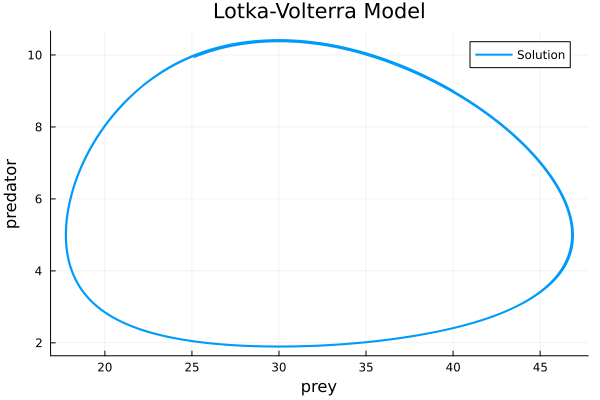

In [ ]:
## Lotka-Volterra equations
@parameters α β γ δ
@independent_variables  t
vars = @variables x(t) y(t) z(t)
Dt = Differential(t)
eqs = [
    Dt(x) ~ α * x - β * x * y,
    Dt(y) ~ δ * x * y - γ * y,
]

params =  Dict([α => 0.1, 
                β => 0.02, 
                δ => 0.01,
                γ => 0.3])
measured_quantities = [z ~ x + y]  # Example of a measured quantity
@named sys = ODESystem(eqs, t, [x, y], [α, β, γ, δ]; observed = measured_quantities, defaults = params)
sys = complete(sys)


u0 = Dict([x => 40.0, y => 9.0])
tspan = (0.0, 80.0)
dt = 0.1

sys = complete(sys)
odefun = ODEFunction(sys, unknowns(sys), parameters(sys))
prob = ODEProblem(odefun, [40.0, 9.0], tspan, [0.1, 0.02, 0.01, 0.3])
sol = solve(prob, Tsit5(), saveat=dt)
data = hcat(sol.u...)'
timedata = sol.t
plot(sol, vars=(x, y), xlabel="prey", ylabel="predator",
     title="Lotka-Volterra Model", label="Solution",
     legend=:topright, linewidth=2, markersize=4)


In [ ]:
#Bifurcation analysis
using BifurcationKit
bif_par = α#, β, γ, δ]
p_start = [α => 0.1, β => 0.02, γ => 0.3, δ => 0.01]
u0_guess = [x => 40.0, y => 9.0]
plot_var = x
bif_prob = BifurcationProblem(sys, u0_guess, p_start, bif_par; plot_var=plot_var)

┌─ Bifurcation Problem with uType Vector{Float64}
├─ Inplace:  true
├─ Dimension:  2
├─ Symmetric: false
└─ Parameter: p1

In [ ]:
p_span = (-4.0, 6.0)
opts_br = ContinuationPar(nev = 4,
    p_min = p_span[1],
    p_max = p_span[2])

ContinuationPar{Float64, DefaultLS, DefaultEig{typeof(real)}}
  dsmin: Float64 0.0001
  dsmax: Float64 0.1
  ds: Float64 0.01
  a: Float64 0.5
  p_min: Float64 -4.0
  p_max: Float64 6.0
  max_steps: Int64 400
  newton_options: NewtonPar{Float64, DefaultLS, DefaultEig{typeof(real)}}
  η: Float64 150.0
  save_to_file: Bool false
  save_sol_every_step: Int64 1
  nev: Int64 4
  save_eig_every_step: Int64 1
  save_eigenvectors: Bool true
  plot_every_step: Int64 10
  tol_stability: Float64 1.0e-10
  detect_fold: Bool true
  detect_bifurcation: Int64 3
  dsmin_bisection: Float64 1.0e-16
  n_inversion: Int64 2
  max_bisection_steps: Int64 25
  tol_bisection_eigenvalue: Float64 1.0e-16
  detect_event: Int64 0
  tol_param_bisection_event: Float64 1.0e-16
  detect_loop: Bool false


In [ ]:
bf  = bifurcationdiagram(bif_prob, PALC(), 3, (args...) -> opts_br; bothside = true)


[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Children number: 0
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 802
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter p1 starts at -1.4834292549217452, ends at 1.6836791549817012
      ├─ Algo: PALC
      └─ Special points:

- #  1, endpoint at p1 ≈ -1.48742766,                                                                     step =  -1
- #  2,       bp at p1 ≈ -0.00002250 ∈ (-0.00002250, +0.00022740), |δp|=2e-04, [converged], δ = (-1,  0), step = 371
- #  3, endpoint at p1 ≈ +1.68767756,                                                                     step = 802


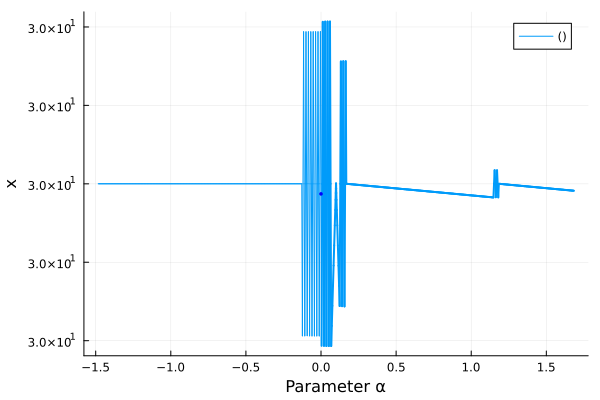

In [ ]:
using Plots
plot(bf;
    putspecialptlegend = false,
    markersize = 2,
    plotfold = false,
    xguide = "Parameter α",
    yguide = "x")